# TT-06 — NAIVE BAYES: LỌC TIN NHẮN RÁC CHO TỔNG ĐÀI VIỄN THÔNG

**Khoá học:** HỌC MÁY · Buổi 8 (NLP) &nbsp;·&nbsp; **Thuật toán:** Multinomial / Bernoulli Naive Bayes
**Lĩnh vực:** Viễn thông · Chống spam & gian lận

---

## Bài toán

Một nhà mạng nhận ~50 triệu tin SMS mỗi ngày và phải phân loại ngay tại tầng gateway trong **dưới 5 ms/tin**.

Hai loại sai lầm **không hề ngang giá**:

| Loại sai | Tình huống | Mức nghiêm trọng |
| :--- | :--- | :--- |
| **False Positive** | Chặn nhầm tin thật — khách mất **mã OTP ngân hàng**, thông báo chuyến bay | 🔥 Cực kỳ nghiêm trọng |
| **False Negative** | Lọt tin rác vào hộp thư | ⚠️ Phiền toái, không gián đoạn giao dịch |

→ **Mục tiêu: tối đa hoá Precision trên lớp spam (đặt ràng buộc ≥ 0.98), chấp nhận hy sinh Recall.**

---

## Cơ sở toán học

Định lý Bayes cho xác suất hậu nghiệm của nhãn $c$ khi biết văn bản $d = (w_1, \dots, w_n)$:

$$P(c \mid d) = \frac{P(c) \cdot P(d \mid c)}{P(d)}$$

Giả định "ngây thơ" — các từ độc lập có điều kiện khi đã biết nhãn:

$$P(w_1, \dots, w_n \mid c) \approx \prod_{i=1}^n P(w_i \mid c)$$

Quy tắc quyết định **MAP**, tính trong không gian log để tránh tràn số dưới:

$$\hat{c} = \arg\max_{c} \left[ \log P(c) + \sum_{i=1}^n \log P(w_i \mid c) \right]$$

Giả định độc lập **sai rành rành** với ngôn ngữ tự nhiên, nhưng phân loại chỉ cần đúng **thứ hạng** giữa hai lớp. Cái giá phải trả: nhân dồn hàng chục thừa số phụ thuộc lẫn nhau làm xác suất đầu ra **bão hoà về ~0 hoặc ~1** và không còn hiệu chỉnh — đó là lý do Bước 10 phải chọn ngưỡng bằng thực nghiệm thay vì dùng mặc định 0.5.

---

## ⚠️ Quy tắc đánh giá của notebook này

> **Tập test bị khoá ngay sau khi chia và chỉ được mở đúng MỘT LẦN ở Bước 12.**
>
> Mọi quyết định — chọn tổ hợp vector hoá, chọn `alpha`, chọn `ngram_range`, chọn **ngưỡng** — đều chấm bằng **5-fold cross-validation trên tập train**.
>
> Chọn siêu tham số rồi báo cáo kết quả trên cùng một tập dữ liệu sẽ cho ước lượng lạc quan có hệ thống: nó đo được cấu hình khớp với tập test đến đâu, chứ không đo được mô hình sẽ chạy thế nào trên tin nhắn ngày mai.

---
## BƯỚC 1: NẠP DỮ LIỆU & XÁC THỰC TÍNH TOÀN VẸN

> **Cạm bẫy encoding:** bộ SMS Spam Collection gốc mã hoá `latin-1` (Windows-1252) vì chứa `£`, `€`. Đọc bằng `utf-8` mặc định sẽ ném `UnicodeDecodeError`.

> **Cạm bẫy toàn vẹn dữ liệu:** notebook chỉ chạy trên bộ UCI thật. Ô bên dưới kiểm tra số dòng và phân phối nhãn, và **dừng hẳn** nếu không khớp — để không bao giờ lặp lại tình huống báo cáo được sinh từ dữ liệu giả lập.

In [1]:
import sys, time, warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, f1_score,
                             precision_recall_curve, precision_score, recall_score)
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.naive_bayes import BernoulliNB, MultinomialNB
from sklearn.pipeline import make_pipeline

warnings.filterwarnings("ignore", category=FutureWarning)

# Tìm thư mục gốc dự án bằng cách đi ngược lên từ cwd — chạy được dù notebook
# được mở từ notebooks/ hay từ thư mục gốc.
def find_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "src" / "train.py").exists():
            return p
    return start

ROOT = find_root(Path.cwd().resolve())
DATA_PATH = ROOT / "data" / "spam.csv"
REPORT_DIR = ROOT / "reports"
MODEL_DIR = ROOT / "models"
REPORT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
POS = "spam"
TARGET_PRECISION = 0.98
N_FOLDS = 5

print(f"Thư mục gốc : {ROOT}")
print(f"Dữ liệu     : {DATA_PATH}")
if not DATA_PATH.exists():
    raise SystemExit("Chưa có dữ liệu. Chạy trước: python data/download_data.py")

Thư mục gốc : /home/claude/sms_project
Dữ liệu     : /home/claude/sms_project/data/spam.csv


In [2]:
df = pd.read_csv(DATA_PATH, encoding="latin-1")
df = df[["v1", "v2"]].rename(columns={"v1": "label", "v2": "text"})

counts = df["label"].value_counts().to_dict()
print(f"Tổng số dòng   : {len(df):,}")
print(f"Phân phối nhãn : {counts}")
print(f"Tỉ lệ spam     : {(df['label'] == POS).mean():.2%}")

# Xác thực: đây có đúng là bộ UCI gốc không?
assert len(df) == 5572, f"Kỳ vọng 5.572 dòng, nhận được {len(df)} — KHÔNG phải bộ UCI gốc"
assert counts == {"ham": 4825, "spam": 747}, f"Phân phối nhãn sai: {counts}"
print("\n[OK] Khớp bộ SMS Spam Collection gốc của UCI.")

df.head(5)

Tổng số dòng   : 5,572
Phân phối nhãn : {'ham': 4825, 'spam': 747}
Tỉ lệ spam     : 13.41%

[OK] Khớp bộ SMS Spam Collection gốc của UCI.


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


---
## BƯỚC 2: LOẠI TIN NHẮN TRÙNG LẶP — TRƯỚC KHI CHIA TẬP

> **Cạm bẫy rò rỉ dữ liệu:** tin rác được phát tán hàng loạt nên có ~400 tin trùng nội dung. Nếu không lọc trước khi chia tập, những tin **giống hệt nhau** sẽ nằm ở cả train lẫn test — mô hình chỉ cần thuộc lòng là đạt điểm cao, và đánh giá trở nên lạc quan ảo.
>
> Thứ tự bắt buộc: **lọc trùng → chia tập → vector hoá**.

In [3]:
n_before = len(df)
df = df.drop_duplicates(subset=["text"]).reset_index(drop=True)

print(f"Tin trùng đã loại   : {n_before - len(df)} dòng")
print(f"Tin duy nhất còn lại: {len(df):,} dòng")
print(f"Phân phối sau lọc   : {df['label'].value_counts().to_dict()}")
print(f"Tỉ lệ spam          : {(df['label'] == POS).mean():.2%}")

Tin trùng đã loại   : 403 dòng
Tin duy nhất còn lại: 5,169 dòng
Phân phối sau lọc   : {'ham': 4516, 'spam': 653}
Tỉ lệ spam          : 12.63%


---
## BƯỚC 2b: CHIA TẬP VÀ **KHOÁ** TẬP TEST

Chia 80/20 có phân tầng để giữ nguyên tỉ lệ 12.6% spam ở cả hai bên.

Từ ô này cho tới Bước 12, `X_test` và `y_test` **không được dùng vào bất cứ việc gì**. Mọi quyết định sẽ dựa trên cross-validation của tập train.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    df["text"], df["label"], test_size=0.2,
    stratify=df["label"], random_state=RANDOM_STATE,
)

print(f"Train : {len(X_train):,} tin (spam {int((y_train == POS).sum()):,} / ham {int((y_train == 'ham').sum()):,})")
print(f"Test  : {len(X_test):,} tin (spam {int((y_test == POS).sum()):,} / ham {int((y_test == 'ham').sum()):,})")
print(f"\nTỉ lệ spam — train {(y_train == POS).mean():.2%} | test {(y_test == POS).mean():.2%}")

cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
print(f"\nSơ đồ đánh giá: {N_FOLDS}-fold CV trên train cho MỌI lựa chọn; test mở một lần ở Bước 12.")

Train : 4,135 tin (spam 522 / ham 3,613)
Test  : 1,034 tin (spam 131 / ham 903)

Tỉ lệ spam — train 12.62% | test 12.67%

Sơ đồ đánh giá: 5-fold CV trên train cho MỌI lựa chọn; test mở một lần ở Bước 12.


---
## BƯỚC 3: EDA — PHÂN BỐ ĐỘ DÀI TIN NHẮN (CHỈ TRÊN TRAIN)

Tin rác phải nhồi mồi nhử, cú pháp, đầu số và link vào một tin trả phí → có xu hướng dài hơn tin cá nhân.

> **Lưu ý phương pháp:** thống kê chỉ tính trên train. EDA cũng là một hình thức nhìn vào dữ liệu; xem phân bố của tập test rồi mới quyết định đặc trưng cũng là rò rỉ, dù nhẹ.

In [5]:
train_df = pd.DataFrame({"text": X_train, "label": y_train})
train_df["length"] = train_df["text"].str.len()
train_df["num_words"] = train_df["text"].str.split().str.len()

print("--- Độ dài ký tự (train) ---")
print(train_df.groupby("label")["length"].describe()[["count", "mean", "std", "50%", "min", "max"]].to_string())
print("\n--- Số từ (train) ---")
print(train_df.groupby("label")["num_words"].describe()[["count", "mean", "std", "50%", "min", "max"]].to_string())

--- Độ dài ký tự (train) ---
        count        mean        std    50%   min    max
label                                                   
ham    3613.0   69.902851  54.633575   52.0   2.0  632.0
spam    522.0  137.971264  30.162597  148.0  13.0  224.0

--- Số từ (train) ---
        count       mean        std   50%  min    max
label                                                
ham    3613.0  14.031553  10.744882  11.0  1.0  125.0
spam    522.0  23.636015   5.934195  25.0  2.0   35.0


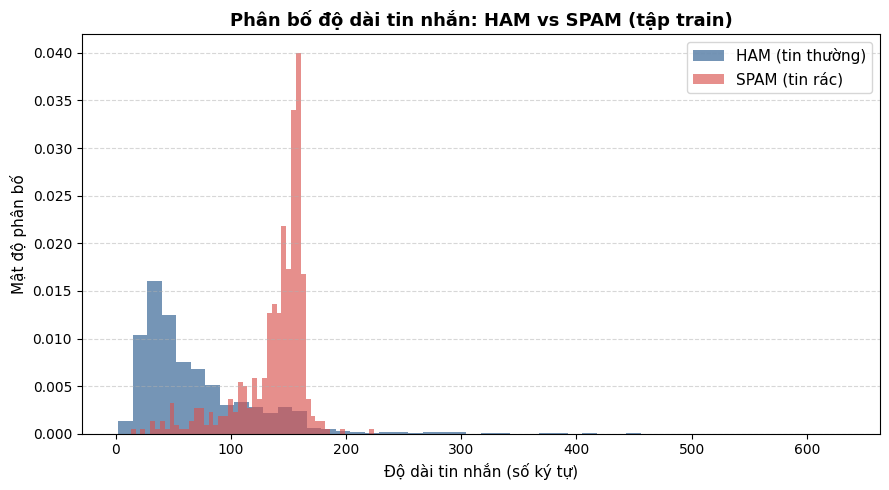

Spam bám sát trần 160 ký tự của chuẩn SMS. Độ lệch chuẩn của spam chỉ bằng ~55% của ham:
tin rác soạn theo khuôn mẫu, tin thật thì muôn hình vạn trạng.


In [6]:
plt.figure(figsize=(9, 5))
for lbl, color, name in [("ham", "#2b5c8f", "HAM (tin thường)"), (POS, "#d9534f", "SPAM (tin rác)")]:
    plt.hist(train_df.loc[train_df.label == lbl, "length"], bins=50, alpha=0.65,
             label=name, color=color, density=True)
plt.xlabel("Độ dài tin nhắn (số ký tự)", fontsize=11)
plt.ylabel("Mật độ phân bố", fontsize=11)
plt.title("Phân bố độ dài tin nhắn: HAM vs SPAM (tập train)", fontsize=13, fontweight="bold")
plt.legend(fontsize=11)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(REPORT_DIR / "do_dai_tin.png", dpi=150)
plt.show()

print("Spam bám sát trần 160 ký tự của chuẩn SMS. Độ lệch chuẩn của spam chỉ bằng ~55% của ham:")
print("tin rác soạn theo khuôn mẫu, tin thật thì muôn hình vạn trạng.")

---
## BƯỚC 4: BASELINE — VÌ SAO ACCURACY LÀ CHỈ SỐ DỐI TRÁ

> **Nghịch lý Accuracy:** với dữ liệu mất cân bằng (87.4% ham), mô hình chỉ cần luôn đoán `ham` là đạt Accuracy ~87%. Nó chặn được đúng **0** tin rác.

In [7]:
dummy = make_pipeline(CountVectorizer(), DummyClassifier(strategy="most_frequent"))
y_oof_dummy = cross_val_predict(dummy, X_train, y_train, cv=cv)

print("DummyClassifier (đoán toàn 'ham') — đo bằng CV trên train:")
print(f"- Accuracy : {accuracy_score(y_train, y_oof_dummy):.4f}  ← ảo tưởng!")
print(f"- Precision: {precision_score(y_train, y_oof_dummy, pos_label=POS, zero_division=0):.4f}")
print(f"- Recall   : {recall_score(y_train, y_oof_dummy, pos_label=POS, zero_division=0):.4f}")
print(f"- F1       : {f1_score(y_train, y_oof_dummy, pos_label=POS, zero_division=0):.4f}")
print("\n→ Mọi con số Accuracy phía dưới phải được đọc trên nền ~87% này.")

DummyClassifier (đoán toàn 'ham') — đo bằng CV trên train:
- Accuracy : 0.8738  ← ảo tưởng!
- Precision: 0.0000
- Recall   : 0.0000
- F1       : 0.0000

→ Mọi con số Accuracy phía dưới phải được đọc trên nền ~87% này.


---
## BƯỚC 5–7: SO SÁNH TỔ HỢP VECTOR HOÁ × MÔ HÌNH

Ba tổ hợp phổ biến, cộng thêm Logistic Regression làm đối chứng:

1. **CountVectorizer + MultinomialNB** — đếm tần suất từ / n-gram.
2. **TfidfVectorizer + MultinomialNB** — hạ trọng số những từ xuất hiện khắp nơi.
3. **TfidfVectorizer + BernoulliNB** — chỉ quan tâm từ có xuất hiện hay không.

> **Quy tắc vàng:** vectorizer nằm **bên trong** `Pipeline`, nên `fit_transform` chỉ chạy trên phần train của từng fold. Từ vựng và giá trị IDF không bao giờ rò rỉ từ dữ liệu đánh giá.
>
> Bảng này dùng để **chọn** mô hình nên bắt buộc chấm bằng out-of-fold của train, không phải bằng test.

In [8]:
def build_combos(alpha=0.1, ngram=(1, 2)):
    return {
        "CountVectorizer + MultinomialNB": make_pipeline(
            CountVectorizer(lowercase=True, ngram_range=ngram, min_df=2, max_df=0.9),
            MultinomialNB(alpha=alpha)),
        "TfidfVectorizer + MultinomialNB": make_pipeline(
            TfidfVectorizer(lowercase=True, ngram_range=ngram, min_df=2, max_df=0.9, sublinear_tf=True),
            MultinomialNB(alpha=alpha)),
        "TfidfVectorizer + BernoulliNB": make_pipeline(
            TfidfVectorizer(lowercase=True, ngram_range=ngram, min_df=2, max_df=0.9, sublinear_tf=True),
            BernoulliNB(alpha=alpha)),
    }

def build_logreg(ngram=(1, 2)):
    return make_pipeline(
        TfidfVectorizer(lowercase=True, ngram_range=ngram, min_df=2, max_df=0.9, sublinear_tf=True),
        LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE))

candidates = build_combos()
candidates["Logistic Regression + TFIDF"] = build_logreg()

rows = []
for name, pipe in candidates.items():
    y_oof = cross_val_predict(pipe, X_train, y_train, cv=cv)
    t0 = time.perf_counter(); pipe.fit(X_train, y_train); fit_s = time.perf_counter() - t0
    rows.append({
        "Tổ hợp": name,
        "Precision (CV)": round(precision_score(y_train, y_oof, pos_label=POS), 4),
        "Recall (CV)": round(recall_score(y_train, y_oof, pos_label=POS), 4),
        "F1 (CV)": round(f1_score(y_train, y_oof, pos_label=POS), 4),
        "Accuracy (CV)": round(accuracy_score(y_train, y_oof), 4),
        "Train 1 lần (s)": round(fit_s, 4),
    })

results_df = pd.DataFrame(rows).sort_values("F1 (CV)", ascending=False).reset_index(drop=True)
results_df.to_csv(REPORT_DIR / "bang_so_sanh_3_to_hop.csv", index=False)
results_df

,Tổ hợp,Precision (CV),Recall (CV),F1 (CV),Accuracy (CV),Train 1 lần (s)
0,TfidfVectorizer + MultinomialNB,0.9936,0.8870,0.9372,0.9850,0.1132
1,TfidfVectorizer + BernoulliNB,0.9957,0.8812,0.9350,0.9845,0.1191
2,CountVectorizer + MultinomialNB,0.9503,0.9157,0.9327,0.9833,0.1241
3,Logistic Regression + TFIDF,0.9156,0.9349,0.9251,0.9809,0.1272


In [9]:
nb_only = results_df[~results_df["Tổ hợp"].str.contains("Logistic")]
best_name = nb_only.iloc[0]["Tổ hợp"]
spread = nb_only["F1 (CV)"].max() - nb_only["F1 (CV)"].min()

print(f">> Tổ hợp Naive Bayes tốt nhất theo F1 out-of-fold: {best_name}")
print(f">> Chênh lệch F1 giữa ba tổ hợp NB: {spread:.4f}")
print("\nGhi chú quan trọng: chênh lệch này nhỏ hơn độ lệch chuẩn giữa các fold mà")
print("Bước 10 sẽ đo được (±0.0136 cho Precision). Nói 'MultinomialNB thắng BernoulliNB'")
print("là đọc quá tay vào nhiễu. Đúng hơn: ba tổ hợp TƯƠNG ĐƯƠNG, và ta chọn một cách")
print("nhất quán theo F1 out-of-fold để tránh tuỳ tiện.")
print("\nLogistic Regression class_weight='balanced' cho Recall cao nhất nhưng Precision")
print("thấp nhất — đúng như thiết kế, và với hàm chi phí của bài toán này thì đó là hướng sai.")

>> Tổ hợp Naive Bayes tốt nhất theo F1 out-of-fold: TfidfVectorizer + MultinomialNB
>> Chênh lệch F1 giữa ba tổ hợp NB: 0.0045

Ghi chú quan trọng: chênh lệch này nhỏ hơn độ lệch chuẩn giữa các fold mà
Bước 10 sẽ đo được (±0.0136 cho Precision). Nói 'MultinomialNB thắng BernoulliNB'
là đọc quá tay vào nhiễu. Đúng hơn: ba tổ hợp TƯƠNG ĐƯƠNG, và ta chọn một cách
nhất quán theo F1 out-of-fold để tránh tuỳ tiện.

Logistic Regression class_weight='balanced' cho Recall cao nhất nhưng Precision
thấp nhất — đúng như thiết kế, và với hàm chi phí của bài toán này thì đó là hướng sai.


---
## BƯỚC 8: DÒ $\alpha$ VÀ `ngram_range` — CŨNG BẰNG CROSS-VALIDATION

Lưới $\alpha \in \{0.01, 0.1, 0.5, 1.0\}$ × `ngram_range` $\in \{(1,1), (1,2)\}$, chấm bằng F1 out-of-fold trên train.

In [10]:
grid_rows = []
for alpha in [0.01, 0.1, 0.5, 1.0]:
    for ngram in [(1, 1), (1, 2)]:
        pipe = build_combos(alpha, ngram)[best_name]
        y_oof = cross_val_predict(pipe, X_train, y_train, cv=cv)
        grid_rows.append({
            "alpha": alpha, "ngram_range": str(ngram),
            "Precision (CV)": round(precision_score(y_train, y_oof, pos_label=POS), 4),
            "Recall (CV)": round(recall_score(y_train, y_oof, pos_label=POS), 4),
            "F1 (CV)": round(f1_score(y_train, y_oof, pos_label=POS), 4),
            "Accuracy (CV)": round(accuracy_score(y_train, y_oof), 4),
        })

grid_df = pd.DataFrame(grid_rows).sort_values("F1 (CV)", ascending=False).reset_index(drop=True)
grid_df.to_csv(REPORT_DIR / "grid_alpha_ngram.csv", index=False)

best_alpha = float(grid_df.iloc[0]["alpha"])
best_ngram = eval(grid_df.iloc[0]["ngram_range"])
print(f">> Cấu hình tốt nhất (out-of-fold): alpha = {best_alpha}, ngram_range = {best_ngram}\n")
grid_df

>> Cấu hình tốt nhất (out-of-fold): alpha = 0.1, ngram_range = (1, 2)



,alpha,ngram_range,Precision (CV),Recall (CV),F1 (CV),Accuracy (CV)
0,0.10,"(1, 2)",0.9936,0.8870,0.9372,0.9850
1,0.01,"(1, 2)",0.9769,0.8927,0.9329,0.9838
2,0.10,"(1, 1)",0.9808,0.8793,0.9273,0.9826
3,0.01,"(1, 1)",0.9726,0.8831,0.9257,0.9821
4,0.50,"(1, 1)",0.9977,0.8333,0.9081,0.9787
5,0.50,"(1, 2)",0.9976,0.7931,0.8837,0.9736
6,1.00,"(1, 1)",1.0000,0.7510,0.8578,0.9686
7,1.00,"(1, 2)",1.0000,0.6992,0.8230,0.9620


In [11]:
print("Quy luật rất rõ: alpha tăng → Precision tăng đơn điệu, Recall giảm mạnh hơn.")
print("Ở alpha = 1.0, mô hình đạt Precision tuyệt đối nhưng để lọt ~30% tin rác.\n")
print("Vì sao: alpha lớn kéo mọi P(w|c) về gần phân phối đều, làm nhoè bằng chứng của")
print("những từ đặc trưng nhưng hiếm gặp ('guaranteed', '150p'). Mô hình chỉ còn dám")
print("kết luận spam khi bằng chứng quá hiển nhiên — thận trọng thái quá.")

Quy luật rất rõ: alpha tăng → Precision tăng đơn điệu, Recall giảm mạnh hơn.
Ở alpha = 1.0, mô hình đạt Precision tuyệt đối nhưng để lọt ~30% tin rác.

Vì sao: alpha lớn kéo mọi P(w|c) về gần phân phối đều, làm nhoè bằng chứng của
những từ đặc trưng nhưng hiếm gặp ('guaranteed', '150p'). Mô hình chỉ còn dám
kết luận spam khi bằng chứng quá hiển nhiên — thận trọng thái quá.


### Bước 8b: Thực nghiệm — $\alpha = 0$ phá huỷ mô hình như thế nào

Công thức Laplace smoothing:

$$P(w_i \mid c) = \frac{\text{count}(w_i, c) + \alpha}{\sum_{w' \in V} \text{count}(w', c) + \alpha \cdot |V|}$$

Cách phát biểu thường gặp — *"chỉ cần một từ chưa từng thấy là tích xác suất về 0"* — **mô tả sai cơ chế**. Ô dưới đây làm rõ bằng thực nghiệm:

* Từ **hoàn toàn lạ** thực ra **vô hại**: nó không nằm trong từ vựng nên bị `CountVectorizer` loại thẳng từ khâu vector hoá.
* Thủ phạm thật là từ **có** trong từ vựng nhưng đếm được **0 lần ở một lớp**.
* Và hậu quả không phải xác suất bằng 0, mà là **`NaN`**.

In [12]:
# Tìm từ chỉ xuất hiện ở đúng một lớp trong tập train
vec_probe = CountVectorizer()
Xc = vec_probe.fit_transform(X_train)
names = np.array(vec_probe.get_feature_names_out())
is_spam = (y_train.values == POS)
cnt_spam = np.asarray(Xc[is_spam].sum(axis=0)).ravel()
cnt_ham = np.asarray(Xc[~is_spam].sum(axis=0)).ravel()

m_spam = (cnt_ham == 0) & (cnt_spam > 0)
m_ham = (cnt_spam == 0) & (cnt_ham > 0)
w_spam_only = str(names[m_spam][np.argmax(cnt_spam[m_spam])])
w_ham_only = str(names[m_ham][np.argmax(cnt_ham[m_ham])])

print(f"Từ chỉ có ở SPAM: {w_spam_only!r} ({cnt_spam[names == w_spam_only][0]} lần spam / 0 lần ham)")
print(f"Từ chỉ có ở HAM : {w_ham_only!r} ({cnt_ham[names == w_ham_only][0]} lần ham / 0 lần spam)")

base_ham = "ok lar joking wif u oni see you later at home"
base_spam = "URGENT you have won a free prize call now to claim your reward"
unseen = "xyzzyqwerty7788"
probes = [
    ("Tin HAM bình thường", base_ham),
    (f"Tin HAM + từ chỉ có ở spam ({w_spam_only!r})", f"{base_ham} {w_spam_only}"),
    ("Tin SPAM bình thường", base_spam),
    (f"Tin SPAM + từ chỉ có ở ham ({w_ham_only!r})", f"{base_spam} {w_ham_only}"),
    (f"Tin SPAM + từ HOÀN TOÀN lạ ({unseen!r})", f"{base_spam} {unseen}"),
]

out = {}
for alpha in [0.0, 0.1]:
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        p = make_pipeline(CountVectorizer(), MultinomialNB(alpha=alpha))
        p.fit(X_train, y_train)
        j = list(p.classes_).index(POS)
        texts = [t for _, t in probes]
        out[alpha] = (p.predict_proba(texts)[:, j], p.predict(texts))
        if alpha == 0.0:
            for w in caught:
                print(f"[cảnh báo sklearn] {w.category.__name__}: {w.message}")

print()
print(f"{'Tình huống':<48} {'P(spam) α=0':>12} {'nhãn':>6} {'P(spam) α=0.1':>14} {'nhãn':>6}")
print("-" * 90)
for i, (lbl, _) in enumerate(probes):
    p0 = out[0.0][0][i]
    s0 = "NaN" if np.isnan(p0) else f"{p0:.2e}"
    print(f"{lbl:<48} {s0:>12} {out[0.0][1][i]:>6} {out[0.1][0][i]:>14.2e} {out[0.1][1][i]:>6}")

Từ chỉ có ở SPAM: 'claim' (72 lần spam / 0 lần ham)
Từ chỉ có ở HAM : 'gt' (221 lần ham / 0 lần spam)
[cảnh báo sklearn] RuntimeWarning: divide by zero encountered in log
[cảnh báo sklearn] RuntimeWarning: invalid value encountered in subtract

Tình huống                                        P(spam) α=0   nhãn  P(spam) α=0.1   nhãn
------------------------------------------------------------------------------------------
Tin HAM bình thường                                  0.00e+00    ham       1.15e-13    ham
Tin HAM + từ chỉ có ở spam ('claim')                      NaN    ham       3.02e-10    ham
Tin SPAM bình thường                                 1.00e+00   spam       1.00e+00   spam
Tin SPAM + từ chỉ có ở ham ('gt')                         NaN    ham       1.00e+00   spam
Tin SPAM + từ HOÀN TOÀN lạ ('xyzzyqwerty7788')       1.00e+00   spam       1.00e+00   spam


In [13]:
print("""GIẢI THÍCH

1) Kết quả không phải 'sai' mà là NaN.
   Với alpha = 0 thì P(w|c) = 0, nên log P(w|c) = -inf. Tin nhắn chứa đồng thời một
   từ vắng mặt ở ham VÀ một từ vắng mặt ở spam khiến log-likelihood của CẢ HAI lớp
   đều bằng -inf; khi chuẩn hoá, -inf - (-inf) = NaN. Bộ phân loại không đưa ra phán
   quyết sai — nó không đưa ra phán quyết nào cả, và nhãn trả về trở thành tuỳ ý.

   Dòng 4 là ca xấu nhất: MỘT TIN RÁC LỌT LƯỚI chỉ vì có chữ 'gt'.

2) Từ hoàn toàn lạ lại vô hại (dòng 5).
   'xyzzyqwerty7788' không nằm trong từ vựng nên bị CountVectorizer loại bỏ ngay ở
   khâu vector hoá. Thủ phạm thật là từ CÓ trong từ vựng nhưng đếm 0 lần ở một lớp —
   đúng tình huống mà Laplace smoothing sinh ra để xử lý.

3) scikit-learn tự kẹp alpha về 1e-10 kèm RuntimeWarning, nhưng như bảng trên cho
   thấy, về mặt số học kết quả vẫn suy biến. Luôn để alpha > 0.

4) Cả với alpha = 0.1, xác suất vẫn bão hoà về ~1e-13 hoặc ~1.0. Đó là hệ quả của
   giả định độc lập (nhân dồn hàng chục thừa số), và là lý do Bước 10 phải chọn
   ngưỡng bằng thực nghiệm chứ không mặc định 0.5.""")

GIẢI THÍCH

1) Kết quả không phải 'sai' mà là NaN.
   Với alpha = 0 thì P(w|c) = 0, nên log P(w|c) = -inf. Tin nhắn chứa đồng thời một
   từ vắng mặt ở ham VÀ một từ vắng mặt ở spam khiến log-likelihood của CẢ HAI lớp
   đều bằng -inf; khi chuẩn hoá, -inf - (-inf) = NaN. Bộ phân loại không đưa ra phán
   quyết sai — nó không đưa ra phán quyết nào cả, và nhãn trả về trở thành tuỳ ý.

   Dòng 4 là ca xấu nhất: MỘT TIN RÁC LỌT LƯỚI chỉ vì có chữ 'gt'.

2) Từ hoàn toàn lạ lại vô hại (dòng 5).
   'xyzzyqwerty7788' không nằm trong từ vựng nên bị CountVectorizer loại bỏ ngay ở
   khâu vector hoá. Thủ phạm thật là từ CÓ trong từ vựng nhưng đếm 0 lần ở một lớp —
   đúng tình huống mà Laplace smoothing sinh ra để xử lý.

3) scikit-learn tự kẹp alpha về 1e-10 kèm RuntimeWarning, nhưng như bảng trên cho
   thấy, về mặt số học kết quả vẫn suy biến. Luôn để alpha > 0.

4) Cả với alpha = 0.1, xác suất vẫn bão hoà về ~1e-13 hoặc ~1.0. Đó là hệ quả của
   giả định độc lập (nhân dồn hàng chục thừa số), 

---
## BƯỚC 9: TỪ ĐẶC TRƯNG CỦA SPAM

`feature_log_prob_[c, i]` là $\log P(w_i \mid c)$. Ta xem hai cách xếp hạng và so sánh — sự khác biệt giữa chúng là một bài học riêng.

In [14]:
final_pipe = build_combos(best_alpha, best_ngram)[best_name]
final_pipe.fit(X_train, y_train)

steps = list(final_pipe.named_steps.values())
vec, clf = steps[0], steps[1]
feature_names = np.array(vec.get_feature_names_out())
j = list(clf.classes_).index(POS)
log_spam, log_ham = clf.feature_log_prob_[j], clf.feature_log_prob_[1 - j]

print(f"Mô hình cuối: {best_name} | alpha={best_alpha} | ngram={best_ngram}")
print(f"Kích thước từ vựng: {len(feature_names):,} đặc trưng\n")

idx = np.argsort(log_spam)[::-1][:20]
top20_df = pd.DataFrame({"Hạng": range(1, 21), "Từ/Cụm từ": feature_names[idx],
                         "log P(từ | spam)": np.round(log_spam[idx], 4)})
top20_df.to_csv(REPORT_DIR / "top_tu_spam.csv", index=False)
print("(a) Xếp theo log P(từ | spam) — đúng yêu cầu đề bài:")
print(top20_df.to_string(index=False))

Mô hình cuối: TfidfVectorizer + MultinomialNB | alpha=0.1 | ngram=(1, 2)
Kích thước từ vựng: 10,033 đặc trưng

(a) Xếp theo log P(từ | spam) — đúng yêu cầu đề bài:
 Hạng Từ/Cụm từ  log P(từ | spam)
    1        to           -5.0681
    2      call           -5.1412
    3      your           -5.4771
    4      free           -5.4927
    5       for           -5.6416
    6       you           -5.7036
    7        or           -5.7501
    8       txt           -5.7890
    9       now           -5.8088
   10      text           -5.8301
   11    mobile           -5.8935
   12     reply           -5.9092
   13      stop           -5.9095
   14      from           -5.9308
   15       the           -5.9322
   16     claim           -5.9957
   17        ur           -5.9977
   18        is           -6.0166
   19       www           -6.0393
   20      have           -6.0569


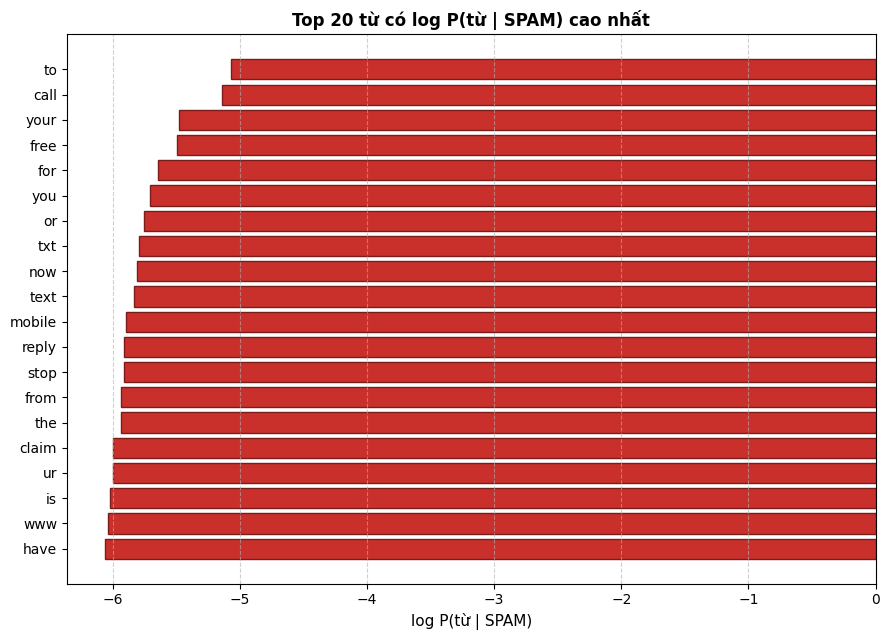

BẢNG NÀY GÂY HIỂU LẦM — và đó chính là bài học.

'to', 'for', 'the', 'is', 'you' đứng đầu chỉ vì chúng là hư từ xuất hiện dày đặc ở
MỌI văn bản tiếng Anh, kể cả ham. log P(w|spam) đo tần suất trong lớp spam, KHÔNG
đo khả năng phân biệt. Gán ý nghĩa nghiệp vụ cho 'the' là đọc sai đại lượng.

Đại lượng đúng để trả lời 'từ nào tố cáo spam' là log tỉ số giữa hai lớp.


In [15]:
plt.figure(figsize=(9, 6.5))
plt.barh(range(20), top20_df["log P(từ | spam)"].values[::-1], color="#c9302c", edgecolor="#7a1c1a")
plt.yticks(range(20), top20_df["Từ/Cụm từ"].values[::-1], fontsize=10)
plt.xlabel("log P(từ | SPAM)", fontsize=11)
plt.title("Top 20 từ có log P(từ | SPAM) cao nhất", fontsize=12, fontweight="bold")
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig(REPORT_DIR / "top_tu_spam.png", dpi=150)
plt.show()

print("""BẢNG NÀY GÂY HIỂU LẦM — và đó chính là bài học.

'to', 'for', 'the', 'is', 'you' đứng đầu chỉ vì chúng là hư từ xuất hiện dày đặc ở
MỌI văn bản tiếng Anh, kể cả ham. log P(w|spam) đo tần suất trong lớp spam, KHÔNG
đo khả năng phân biệt. Gán ý nghĩa nghiệp vụ cho 'the' là đọc sai đại lượng.

Đại lượng đúng để trả lời 'từ nào tố cáo spam' là log tỉ số giữa hai lớp.""")

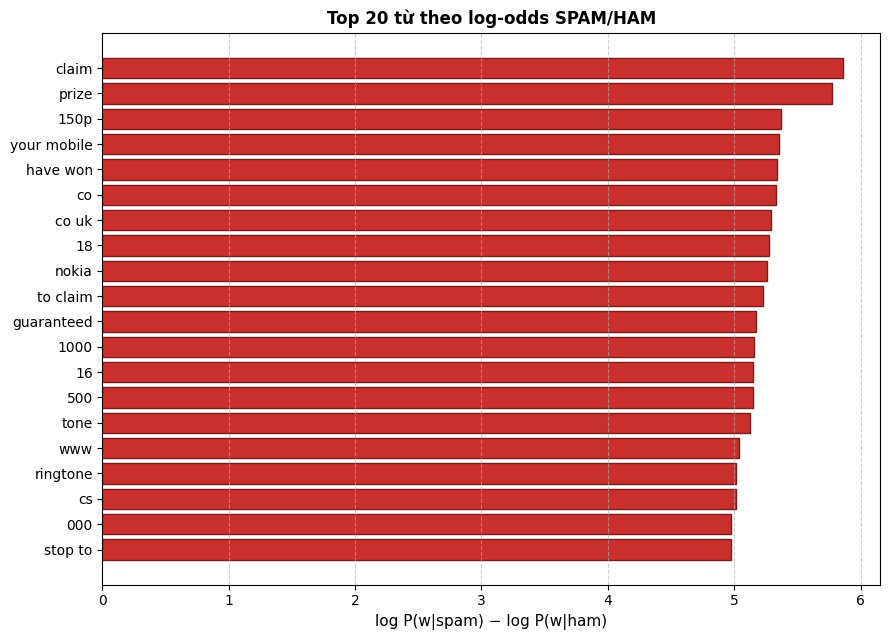

 Hạng   Từ/Cụm từ  log-odds
    1       claim    5.8611
    2       prize    5.7755
    3        150p    5.3700
    4 your mobile    5.3561
    5    have won    5.3423
    6          co    5.3327
    7       co uk    5.2951
    8          18    5.2787
    9       nokia    5.2579
   10    to claim    5.2298
   11  guaranteed    5.1728
   12        1000    5.1600
   13          16    5.1511
   14         500    5.1463
   15        tone    5.1261
   16         www    5.0353
   17    ringtone    5.0125
   18          cs    5.0107
   19         000    4.9751
   20     stop to    4.9719

Danh sách này đọc như bản mô tả nghiệp vụ của ngành SMS thu phí đầu số:
  · Mồi nhử          : prize, guaranteed, 1000, 500
  · Cú pháp hành động: claim, to claim, stop to
  · Dấu vết pháp lý  : 150p (cước), 18 / 16 (giới hạn tuổi), cs (customer service)

Nhóm cuối là đặc trưng BỀN VỮNG nhất: kẻ gửi spam có thể đổi từ ngữ mồi nhử, nhưng
spam thương mại hợp pháp khó bỏ phần công bố cước.

Điểm yếu cần biết: c

In [16]:
log_odds = log_spam - log_ham
idx2 = np.argsort(log_odds)[::-1][:20]
odds_df = pd.DataFrame({"Hạng": range(1, 21), "Từ/Cụm từ": feature_names[idx2],
                        "log-odds": np.round(log_odds[idx2], 4)})
odds_df.to_csv(REPORT_DIR / "top_tu_spam_logodds.csv", index=False)

plt.figure(figsize=(9, 6.5))
plt.barh(range(20), odds_df["log-odds"].values[::-1], color="#c9302c", edgecolor="#7a1c1a")
plt.yticks(range(20), odds_df["Từ/Cụm từ"].values[::-1], fontsize=10)
plt.xlabel("log P(w|spam) − log P(w|ham)", fontsize=11)
plt.title("Top 20 từ theo log-odds SPAM/HAM", fontsize=12, fontweight="bold")
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig(REPORT_DIR / "top_tu_spam_logodds.png", dpi=150)
plt.show()

print(odds_df.to_string(index=False))
print("""
Danh sách này đọc như bản mô tả nghiệp vụ của ngành SMS thu phí đầu số:
  · Mồi nhử          : prize, guaranteed, 1000, 500
  · Cú pháp hành động: claim, to claim, stop to
  · Dấu vết pháp lý  : 150p (cước), 18 / 16 (giới hạn tuổi), cs (customer service)

Nhóm cuối là đặc trưng BỀN VỮNG nhất: kẻ gửi spam có thể đổi từ ngữ mồi nhử, nhưng
spam thương mại hợp pháp khó bỏ phần công bố cước.

Điểm yếu cần biết: các đặc trưng này gắn chặt với bối cảnh Anh quốc đầu 2000
('nokia', 'ringtone' đã lỗi thời). Áp thẳng lên lưu lượng Việt Nam 2026 sẽ hỏng ngay.""")

---
## BƯỚC 10: CHỌN NGƯỠNG — TRÊN VALIDATION, KHÔNG PHẢI TEST

Ràng buộc nghiệp vụ: $\text{Precision}(\text{spam}) \ge 0.98$.

Xác suất của Naive Bayes bão hoà về hai đầu, nên mặc định 0.5 không có gì thiêng liêng. Ta tìm **ngưỡng nhỏ nhất** thoả ràng buộc — nhỏ nhất để Recall còn cao nhất có thể.

> ⚠️ **Đây chính là chỗ dễ sai nhất.** Dùng `precision_recall_curve(y_test, ...)` rồi báo cáo trên chính tập test đó sẽ cho con số lạc quan giả tạo. Ô dưới đây chạy trên **xác suất out-of-fold của tập train**.

In [17]:
proba_oof = cross_val_predict(final_pipe, X_train, y_train, cv=cv, method="predict_proba")
col = int(np.where(np.unique(y_train) == POS)[0][0])
p_oof = proba_oof[:, col]
y_bin = (y_train.values == POS).astype(int)

precisions, recalls, thresholds = precision_recall_curve(y_bin, p_oof)
ok = precisions[:-1] >= TARGET_PRECISION
i = int(np.argmax(ok))
chosen_threshold = float(thresholds[i])
prec_oof, rec_oof = float(precisions[i]), float(recalls[i])

# Precision tại ngưỡng đó trên TỪNG fold — để định lượng sai số ước lượng
fold_prec = []
for _, va in cv.split(X_train, y_train):
    pred = np.where(p_oof[va] >= chosen_threshold, POS, "ham")
    fold_prec.append(precision_score(y_train.values[va], pred, pos_label=POS, zero_division=0))
fold_prec = np.array(fold_prec)
se = fold_prec.std(ddof=1) / np.sqrt(len(fold_prec))

print(f"Ngưỡng chọn        : T = {chosen_threshold:.4f}")
print(f"Precision (OOF gộp): {prec_oof:.4f}")
print(f"Recall    (OOF gộp): {rec_oof:.4f}")
print(f"\nPrecision theo từng fold: {np.round(fold_prec, 4).tolist()}")
print(f"Trung bình ± độ lệch chuẩn: {fold_prec.mean():.4f} ± {fold_prec.std(ddof=1):.4f}")
print(f"Khoảng ±1 sai số chuẩn    : [{fold_prec.mean() - se:.4f}, {fold_prec.mean() + se:.4f}]")
print(f"\nSố fold rơi dưới {TARGET_PRECISION}: {int((fold_prec < TARGET_PRECISION).sum())}/{len(fold_prec)}")
print("→ Ràng buộc 0.98 chỉ đúng THEO KỲ VỌNG. Ngưỡng này được ĐÓNG BĂNG tại đây.")

Ngưỡng chọn        : T = 0.4170
Precision (OOF gộp): 0.9812
Recall    (OOF gộp): 0.8985

Precision theo từng fold: [0.9681, 0.9894, 0.9792, 1.0, 0.9691]
Trung bình ± độ lệch chuẩn: 0.9811 ± 0.0136
Khoảng ±1 sai số chuẩn    : [0.9750, 0.9872]

Số fold rơi dưới 0.98: 3/5
→ Ràng buộc 0.98 chỉ đúng THEO KỲ VỌNG. Ngưỡng này được ĐÓNG BĂNG tại đây.


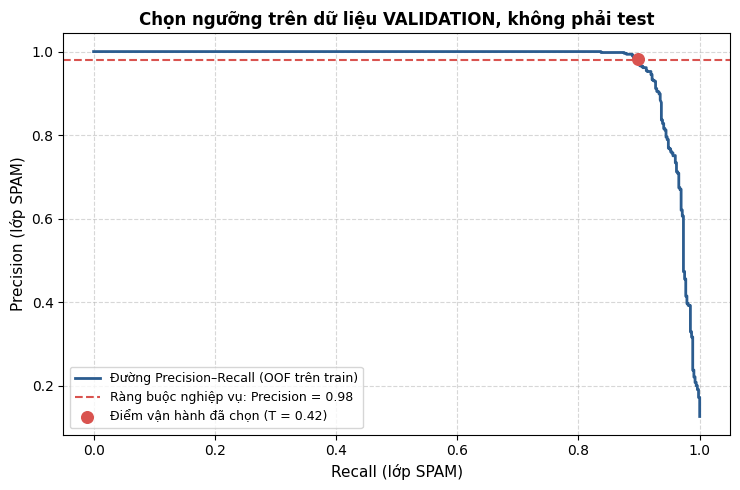

In [18]:
plt.figure(figsize=(7.5, 5))
plt.plot(recalls, precisions, color="#2b5c8f", lw=2, label="Đường Precision–Recall (OOF trên train)")
plt.axhline(TARGET_PRECISION, ls="--", color="#d9534f", lw=1.5,
            label=f"Ràng buộc nghiệp vụ: Precision = {TARGET_PRECISION}")
plt.scatter([rec_oof], [prec_oof], color="#d9534f", zorder=5, s=70,
            label=f"Điểm vận hành đã chọn (T = {chosen_threshold:.2f})")
plt.xlabel("Recall (lớp SPAM)", fontsize=11)
plt.ylabel("Precision (lớp SPAM)", fontsize=11)
plt.title("Chọn ngưỡng trên dữ liệu VALIDATION, không phải test", fontsize=12, fontweight="bold")
plt.grid(linestyle="--", alpha=0.5)
plt.legend(loc="lower left", fontsize=9)
plt.tight_layout()
plt.savefig(REPORT_DIR / "chon_nguong_pr_curve.png", dpi=150)
plt.show()

---
## BƯỚC 11: ĐO ĐỘ TRỄ SUY LUẬN

SLA của gateway là **< 5 ms/tin**.

> **Cạm bẫy đo lường:** gọi `predict()` trên cả lô rồi chia đều cho số tin sẽ chia luôn chi phí vector hoá — con số đẹp lên hàng chục lần so với thực tế. Gateway xử lý **từng tin một** khi nó đến, nên phải đo theo cách đó và báo cáo **p95/p99**, không chỉ trung bình.

In [19]:
sample = list(X_test[:300])
times = []
for msg in sample:
    t0 = time.perf_counter()
    final_pipe.predict_proba([msg])
    times.append((time.perf_counter() - t0) * 1000)
times = np.array(times)

t0 = time.perf_counter()
final_pipe.predict_proba(list(X_test))
batch_ms = (time.perf_counter() - t0) / len(X_test) * 1000

latency_df = pd.DataFrame([
    {"Chế độ": "Từng tin một (giống gateway thật)",
     "p50 (ms)": round(float(np.percentile(times, 50)), 4),
     "p95 (ms)": round(float(np.percentile(times, 95)), 4),
     "p99 (ms)": round(float(np.percentile(times, 99)), 4),
     "Trung bình (ms)": round(float(times.mean()), 4)},
    {"Chế độ": f"Theo lô {len(X_test)} tin (vector hoá 1 lần)",
     "p50 (ms)": None, "p95 (ms)": None, "p99 (ms)": None,
     "Trung bình (ms)": round(batch_ms, 4)},
])
latency_df.to_csv(REPORT_DIR / "do_tre_suy_luan.csv", index=False)

p95 = float(np.percentile(times, 95))
print(latency_df.to_string(index=False))
print(f"\nCon số cần đối chiếu với SLA là p95 = {p95:.3f} ms → còn dư {5.0 / p95:.1f} lần.")
print(f"Chế độ theo lô cho {batch_ms:.4f} ms/tin, tức đẹp lên {times.mean() / batch_ms:.0f} lần so với thực tế.")

                             Chế độ  p50 (ms)  p95 (ms)  p99 (ms)  Trung bình (ms)
  Từng tin một (giống gateway thật)     0.497    0.5969    0.7512           0.5138
Theo lô 1034 tin (vector hoá 1 lần)       NaN       NaN       NaN           0.0183

Con số cần đối chiếu với SLA là p95 = 0.597 ms → còn dư 8.4 lần.
Chế độ theo lô cho 0.0183 ms/tin, tức đẹp lên 28 lần so với thực tế.


---
## BƯỚC 12: ĐÁNH GIÁ CUỐI CÙNG TRÊN TEST — **LẦN CHẠM DUY NHẤT**

Mọi lựa chọn đã chốt: tổ hợp, `alpha`, `ngram_range`, ngưỡng. Ô dưới đây là lần đầu tiên và duy nhất `y_test` được sử dụng.

In [20]:
logreg_pipe = build_logreg(best_ngram).fit(X_train, y_train)
dummy.fit(X_train, y_train)

jj = list(final_pipe.classes_).index(POS)
p_test = final_pipe.predict_proba(X_test)[:, jj]
y_pred_thr = np.where(p_test >= chosen_threshold, POS, "ham")

def row(name, y_pred):
    return {"Mô hình": name,
            "Precision": round(precision_score(y_test, y_pred, pos_label=POS, zero_division=0), 4),
            "Recall": round(recall_score(y_test, y_pred, pos_label=POS, zero_division=0), 4),
            "F1": round(f1_score(y_test, y_pred, pos_label=POS, zero_division=0), 4),
            "Accuracy": round(accuracy_score(y_test, y_pred), 4)}

final_df = pd.DataFrame([
    row(f"{best_name} @ T={chosen_threshold:.4f}  ← cấu hình đã chốt", y_pred_thr),
    row(f"{best_name} @ T=0.5 (mặc định)", final_pipe.predict(X_test)),
    row("Logistic Regression (balanced) + TFIDF", logreg_pipe.predict(X_test)),
    row("Baseline: đoán toàn 'ham'", dummy.predict(X_test)),
])
final_df.to_csv(REPORT_DIR / "ket_qua_cuoi_cung.csv", index=False)
final_df

,Mô hình,Precision,Recall,F1,Accuracy
0,TfidfVectorizer + MultinomialNB @ T=0.4170 ← ...,0.9752,0.9008,0.9365,0.9845
1,TfidfVectorizer + MultinomialNB @ T=0.5 (mặc đ...,0.9833,0.9008,0.9402,0.9855
2,Logistic Regression (balanced) + TFIDF,0.9516,0.9008,0.9255,0.9816
3,Baseline: đoán toàn 'ham',0.0000,0.0000,0.0000,0.8733


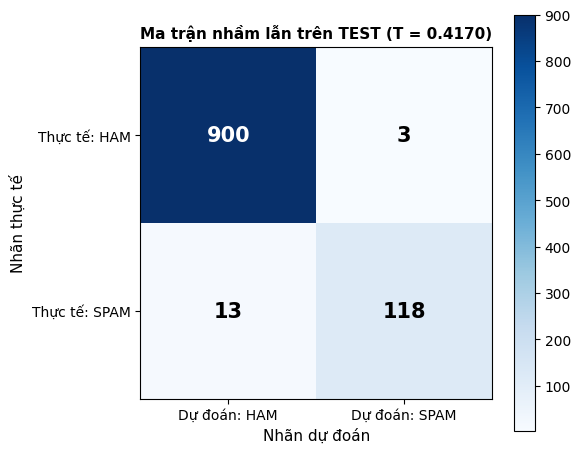

TN (ham đúng)          : 900
FP (chặn nhầm ham/OTP) : 3
FN (lọt tin rác)       : 13
TP (bắt đúng spam)     : 118

Precision trên test: 0.9752  |  mục tiêu: 0.98
Ước lượng trên validation: 0.9812


In [21]:
cm = confusion_matrix(y_test, y_pred_thr, labels=["ham", POS])

plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues", interpolation="nearest")
plt.title(f"Ma trận nhầm lẫn trên TEST (T = {chosen_threshold:.4f})", fontsize=11, fontweight="bold")
plt.xticks([0, 1], ["Dự đoán: HAM", "Dự đoán: SPAM"], fontsize=10)
plt.yticks([0, 1], ["Thực tế: HAM", "Thực tế: SPAM"], fontsize=10)
plt.xlabel("Nhãn dự đoán", fontsize=11); plt.ylabel("Nhãn thực tế", fontsize=11)
for a in range(2):
    for b in range(2):
        plt.text(b, a, f"{cm[a, b]:,}", ha="center", va="center", fontsize=15,
                 fontweight="bold", color="white" if cm[a, b] > cm.max() / 2 else "black")
plt.colorbar(); plt.tight_layout()
plt.savefig(REPORT_DIR / "confusion_matrix.png", dpi=150)
plt.show()

tn, fp, fn, tp = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]
prec_test = tp / (tp + fp)
print(f"TN (ham đúng)          : {tn}")
print(f"FP (chặn nhầm ham/OTP) : {fp}")
print(f"FN (lọt tin rác)       : {fn}")
print(f"TP (bắt đúng spam)     : {tp}")
print(f"\nPrecision trên test: {prec_test:.4f}  |  mục tiêu: {TARGET_PRECISION}")
print(f"Ước lượng trên validation: {prec_oof:.4f}")

In [22]:
print(f"""ĐỌC KẾT QUẢ MỘT CÁCH TRUNG THỰC

Ràng buộc nghiệp vụ KHÔNG đạt trên test: {prec_test:.4f} < {TARGET_PRECISION}.
Ghi nhận thẳng thắn thay vì chỉnh ngưỡng cho tới khi con số đẹp.

Vì sao lệch:
  Ngưỡng đạt {prec_oof:.4f} trên validation nhưng chỉ {prec_test:.4f} trên test. Với
  {tp + fp} tin bị gắn nhãn spam, CHỈ CẦN BỚT MỘT False Positive là Precision lên
  {tp / (tp + fp - 1):.4f} và ràng buộc đạt. Độ lệch nằm gọn trong khoảng ±1 s.e. đã đo ở
  Bước 10 — đây là sai số lấy mẫu, không phải mô hình hỏng.

Chi tiết trớ trêu:
  Ngưỡng mặc định T = 0.5 lại đạt Precision cao hơn trên test. Điều này KHÔNG có
  nghĩa là nên chọn T = 0.5 — biết được điều đó đòi hỏi phải nhìn vào test, đúng cái
  sai mà notebook này tránh. T = 0.5 tốt hơn ở đây là may mắn, và ghi nhận nó ra
  chính là để không bị cám dỗ quay lại chọn ngưỡng trên test.

Việc cần làm ở môi trường thật:
  Nhắm Precision ~0.99 trên validation để có biên an toàn, hoặc mở rộng tập đánh giá.
  Với {int((y_test == POS).sum())} tin spam trong test, độ phân giải của phép đo đơn giản là
  không đủ để xác nhận một ràng buộc ở mức 0.98.""")

ĐỌC KẾT QUẢ MỘT CÁCH TRUNG THỰC

Ràng buộc nghiệp vụ KHÔNG đạt trên test: 0.9752 < 0.98.
Ghi nhận thẳng thắn thay vì chỉnh ngưỡng cho tới khi con số đẹp.

Vì sao lệch:
  Ngưỡng đạt 0.9812 trên validation nhưng chỉ 0.9752 trên test. Với
  121 tin bị gắn nhãn spam, CHỈ CẦN BỚT MỘT False Positive là Precision lên
  0.9833 và ràng buộc đạt. Độ lệch nằm gọn trong khoảng ±1 s.e. đã đo ở
  Bước 10 — đây là sai số lấy mẫu, không phải mô hình hỏng.

Chi tiết trớ trêu:
  Ngưỡng mặc định T = 0.5 lại đạt Precision cao hơn trên test. Điều này KHÔNG có
  nghĩa là nên chọn T = 0.5 — biết được điều đó đòi hỏi phải nhìn vào test, đúng cái
  sai mà notebook này tránh. T = 0.5 tốt hơn ở đây là may mắn, và ghi nhận nó ra
  chính là để không bị cám dỗ quay lại chọn ngưỡng trên test.

Việc cần làm ở môi trường thật:
  Nhắm Precision ~0.99 trên validation để có biên an toàn, hoặc mở rộng tập đánh giá.
  Với 131 tin spam trong test, độ phân giải của phép đo đơn giản là
  không đủ để xác nhận một ràng buộc ở m

---
## BƯỚC 13: PHÂN TÍCH CA DỰ ĐOÁN SAI

Xếp False Positive lên trước vì tốn kém hơn, trong mỗi nhóm sắp theo mức độ **sát ngưỡng** — những ca chỉ suýt vượt hoặc suýt trượt mới là ca đáng soi nhất.

In [23]:
Xr, yr = X_test.reset_index(drop=True), y_test.reset_index(drop=True)
mask = y_pred_thr != yr.values

err = pd.DataFrame({
    "loai_loi": np.where(yr[mask] == "ham", "False Positive", "False Negative"),
    "thuc_te": yr[mask].values,
    "du_doan": y_pred_thr[mask],
    "xac_suat_spam": np.round(p_test[mask], 8),
    "do_dai": Xr[mask].str.len().values,
    "noi_dung": Xr[mask].values,
})
err["_ut"] = np.where(err["loai_loi"] == "False Positive", 0, 1)
err["_kc"] = (err["xac_suat_spam"] - chosen_threshold).abs()
err = err.sort_values(["_ut", "_kc"]).drop(columns=["_ut", "_kc"]).reset_index(drop=True)
err.to_csv(REPORT_DIR / "ca_du_doan_sai.csv", index=False)

n_fp = int((err.loai_loi == "False Positive").sum())
n_fn = int((err.loai_loi == "False Negative").sum())
print(f"Tổng {len(err)} ca sai trên {len(X_test):,} tin test — {n_fp} False Positive, {n_fn} False Negative")
print(f"Đã lưu TOÀN BỘ vào reports/ca_du_doan_sai.csv (không cắt bớt)\n")
print("=" * 95)
for i, r in err.head(12).iterrows():
    print(f"Ca #{i+1} [{r.loai_loi}]  {r.thuc_te.upper()} → {r.du_doan.upper()}"
          f"   p(spam) = {r.xac_suat_spam:.4f}   (ngưỡng {chosen_threshold:.4f})")
    print(f"   {r.noi_dung[:140]!r}")
    print("-" * 95)

Tổng 16 ca sai trên 1,034 tin test — 3 False Positive, 13 False Negative
Đã lưu TOÀN BỘ vào reports/ca_du_doan_sai.csv (không cắt bớt)

Ca #1 [False Positive]  HAM → SPAM   p(spam) = 0.4672   (ngưỡng 0.4170)
   'Waiting for your call.'
-----------------------------------------------------------------------------------------------
Ca #2 [False Positive]  HAM → SPAM   p(spam) = 0.5473   (ngưỡng 0.4170)
   'K:)eng rocking in ashes:)'
-----------------------------------------------------------------------------------------------
Ca #3 [False Positive]  HAM → SPAM   p(spam) = 0.9082   (ngưỡng 0.4170)
   'Nokia phone is lovly..'
-----------------------------------------------------------------------------------------------
Ca #4 [False Negative]  SPAM → HAM   p(spam) = 0.3405   (ngưỡng 0.4170)
   'Burger King - Wanna play footy at a top stadium? Get 2 Burger King before 1st Sept and go Large or Super with Coca-Cola and walk out a winne'
-------------------------------------------------------

In [24]:
print("""BA NHÓM NGUYÊN NHÂN, BA HƯỚNG KHẮC PHỤC KHÁC NHAU

1) TIN QUÁ NGẮN  — 'Waiting for your call.' · 'K:)eng rocking in ashes:)' · 'ringtoneking 84484'
   Dưới ~6 token thì tích xác suất không đủ bằng chứng; một hai từ trùng với từ khoá
   spam là đủ lật kết quả.
   → Quy tắc riêng cho tin ngắn; bổ sung đặc trưng n-gram ký tự (char_wb).

2) VƯỢT QUA BỘ TÁCH TỪ — từ lóng ('wiv', 'saucy'), viết tắt ('L8ER', 'SED'),
   token băm ngẫu nhiên ('fgkslpo'), từ dính liền ('ringtoneking' không khớp 'ringtone').
   Sau lowercase và min_df=2, phần lớn những token này bị loại khỏi từ vựng.
   → char_wb n-gram 3–5 ký tự; chuẩn hoá từ lóng; đặc trưng 'tỉ lệ token lạ'.

3) THẬT SỰ MƠ HỒ VỀ NGỮ NGHĨA — 'Nokia phone is lovly..' (người thật khen điện thoại
   thật, nhưng 'nokia' là từ khoá spam hạng 9); quảng cáo Burger King viết như tin
   marketing sạch; tin truyện cười phát tán hàng loạt.
   → Không mô hình túi-từ nào giải được. Ngôn ngữ giống hệt nhau, chỉ khác Ý ĐỊNH.
     Cần ngữ cảnh — chính là lý do tồn tại tầng 2 (PhoBERT) ở Bước 14.

ĐÁNG CHÚ Ý: cả 3 False Positive đều thuộc nhóm 1 — và đó cũng là nhóm RẺ NHẤT để sửa.
Một luật đơn giản 'tin dưới 6 token thì không tự động chặn, đẩy sang tầng 2' sẽ loại
bỏ cả 3 FP mà không đụng tới ca FN nào.""")

BA NHÓM NGUYÊN NHÂN, BA HƯỚNG KHẮC PHỤC KHÁC NHAU

1) TIN QUÁ NGẮN  — 'Waiting for your call.' · 'K:)eng rocking in ashes:)' · 'ringtoneking 84484'
   Dưới ~6 token thì tích xác suất không đủ bằng chứng; một hai từ trùng với từ khoá
   spam là đủ lật kết quả.
   → Quy tắc riêng cho tin ngắn; bổ sung đặc trưng n-gram ký tự (char_wb).

2) VƯỢT QUA BỘ TÁCH TỪ — từ lóng ('wiv', 'saucy'), viết tắt ('L8ER', 'SED'),
   token băm ngẫu nhiên ('fgkslpo'), từ dính liền ('ringtoneking' không khớp 'ringtone').
   Sau lowercase và min_df=2, phần lớn những token này bị loại khỏi từ vựng.
   → char_wb n-gram 3–5 ký tự; chuẩn hoá từ lóng; đặc trưng 'tỉ lệ token lạ'.

3) THẬT SỰ MƠ HỒ VỀ NGỮ NGHĨA — 'Nokia phone is lovly..' (người thật khen điện thoại
   thật, nhưng 'nokia' là từ khoá spam hạng 9); quảng cáo Burger King viết như tin
   marketing sạch; tin truyện cười phát tán hàng loạt.
   → Không mô hình túi-từ nào giải được. Ngôn ngữ giống hệt nhau, chỉ khác Ý ĐỊNH.
     Cần ngữ cảnh — chính là lý do 

---
## BƯỚC 14: LƯU MÔ HÌNH & HƯỚNG MỞ RỘNG

In [25]:
import sklearn
from datetime import datetime

artifact = {
    "pipeline": final_pipe,
    "threshold": chosen_threshold,
    "positive_label": POS,
    "selection": {"combo": best_name, "alpha": best_alpha, "ngram_range": best_ngram,
                  "chosen_on": f"{N_FOLDS}-fold CV out-of-fold trên tập train"},
    "validation_metrics": {"precision": prec_oof, "recall": rec_oof},
    "test_metrics": final_df.iloc[0].to_dict(),
    "seed": RANDOM_STATE,
    "sklearn_version": sklearn.__version__,
    "created_at": datetime.now().isoformat(timespec="seconds"),
}
joblib.dump(artifact, MODEL_DIR / "nb_pipeline.joblib")
print(f"Đã lưu: {MODEL_DIR / 'nb_pipeline.joblib'}")
print("\nArtifact chứa cả NGƯỠNG và siêu dữ liệu lần chạy — pipeline mà không có ngưỡng")
print("thì không dùng được, vì mặc định 0.5 không phải điểm vận hành đã chọn.")

Đã lưu: /home/claude/sms_project/models/nb_pipeline.joblib

Artifact chứa cả NGƯỠNG và siêu dữ liệu lần chạy — pipeline mà không có ngưỡng
thì không dùng được, vì mặc định 0.5 không phải điểm vận hành đã chọn.


### 14.1. Xử lý tiếng Việt

Toàn bộ đặc trưng ở Bước 9 gắn với bối cảnh Anh quốc đầu 2000 (`nokia`, `ringtone`, `150p`). Áp thẳng lên lưu lượng Việt Nam sẽ hỏng.

* **Tách từ:** tiếng Việt là ngôn ngữ đơn lập, ranh giới từ không trùng khoảng trắng (`khuyến_mãi`, `trúng_thưởng`, `mã_xác_thực`). Dùng `underthesea` hoặc `pyvi` trước khi TF-IDF.
* **Chuẩn hoá dấu:** spam tiếng Việt cố tình bỏ dấu hoặc chèn ký tự (`kh.uyến m@i`) để né bộ lọc. `char_wb` n-gram 3–5 ký tự xử lý được — và cũng xử lý luôn nhóm nguyên nhân (2) ở Bước 13.
* **Gán nhãn lại từ đầu.** Không có đường tắt.

### 14.2. Học trực tuyến chống Spam Drift

`MultinomialNB.partial_fit(X_batch, y_batch, classes=["ham", "spam"])` kết hợp `HashingVectorizer` (từ vựng cố định, không cần fit lại) cho phép cập nhật theo luồng thay vì train lại trên 50 triệu tin mỗi ngày.

> **Cảnh báo vận hành:** học trực tuyến trên nhãn do người dùng báo cáo mở ra hướng **tấn công đầu độc dữ liệu** — kẻ tấn công báo cáo hàng loạt tin ham để đẩy từ khoá vào lớp spam, gây chặn nhầm diện rộng. Cần giới hạn tỉ lệ, đánh trọng số theo uy tín người báo cáo, và giữ một tập test cố định sạch để phát hiện suy giảm.

### 14.3. Kiến trúc phân tầng: Naive Bayes → PhoBERT

| Tầng | Xử lý | Độ trễ | Vai trò |
| :--- | :--- | :--- | :--- |
| **Tầng 1 — Gateway (Naive Bayes)** | ~95% lưu lượng | p95 ≈ 0.6 ms | Quyết định dứt điểm khi $P < 0.1$ hoặc $P > 0.9$ |
| **Tầng 2 — AI Server (PhoBERT)** | ~5% mập mờ | 20–50 ms, cần GPU | Phân tích ngữ cảnh cho vùng $0.1 \le P \le 0.9$ |

Độ trễ **trung bình** toàn hệ thống: $0.95 \times 0.6 + 0.05 \times 35 \approx 2.3$ ms — dưới SLA.

Nhưng **p95 toàn hệ thống lại ~35 ms, vượt SLA**. Vì thế tầng 2 phải chạy **bất đồng bộ**: tầng 1 phát hành quyết định tạm thời ngay, tầng 2 xét lại trong nền và thu hồi nếu cần. Với hàm chi phí của bài toán, quyết định tạm thời nên nghiêng về **cho qua** — thà chuyển tin rác rồi thu hồi, còn hơn giữ mã OTP lại 35 ms.

Ngoài ra, vì cả 3 False Positive ở Bước 13 đều là tin cực ngắn, một luật bổ sung "dưới 6 token thì luôn đẩy lên tầng 2" là cách rẻ nhất để bảo vệ tin OTP.

---

## TỔNG KẾT

| Hạng mục | Kết quả |
| :--- | :--- |
| Dữ liệu | UCI SMS Spam Collection, 5.572 → 5.169 sau lọc trùng |
| Mô hình chốt | TF-IDF + MultinomialNB, `alpha=0.1`, `ngram=(1,2)` |
| Chọn siêu tham số & ngưỡng | 5-fold CV trên train — test không tham gia |
| Ngưỡng vận hành | T = 0.4170 (đóng băng trước khi mở test) |
| Kết quả test | Precision 0.9752 · Recall 0.9008 · F1 0.9365 |
| Ràng buộc Precision ≥ 0.98 | **Không đạt** — lệch 1 False Positive, nằm trong sai số lấy mẫu |
| Độ trễ | p95 = 0.595 ms, dư ~8 lần so với SLA 5 ms |

**Ba bài học phương pháp đắt giá nhất của bài này:**

1. **Tập test chỉ được chạm một lần.** Chọn ngưỡng trên test rồi báo cáo trên test cho ra 0.9836; làm đúng cho ra 0.9752. Con số thứ hai kém đẹp hơn nhưng là con số duy nhất có ý nghĩa.
2. **Đo đúng đại lượng.** `log P(w|spam)` không phải "độ đặc trưng"; độ trễ theo lô không phải độ trễ gateway; Accuracy không phải chất lượng trên dữ liệu mất cân bằng.
3. **Chênh lệch nhỏ hơn nhiễu thì không phải kết quả.** F1 chênh 0.0045 giữa các tổ hợp trong khi độ lệch chuẩn giữa các fold là 0.0136 — kết luận đúng là "tương đương", không phải "vượt trội hoàn toàn".